In [45]:
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, log_loss, accuracy_score

from xgboost import XGBClassifier

In [46]:
# =========================
# LOAD DATA
# =========================

train_df = pd.read_csv(r"C:\Users\Yuvraj Bhavsar\OneDrive\Desktop\competition\DigiCow Farmer Training Adoption Challenge\Train.csv")
test_df  = pd.read_csv(r"C:\Users\Yuvraj Bhavsar\OneDrive\Desktop\competition\DigiCow Farmer Training Adoption Challenge\Test.csv")

In [47]:
train_df.head()

,ID,farmer_name,training_day,gender,registration,age,group_name,belong_to_cooperative,county,subcounty,ward,adopted_within_07_days,adopted_within_90_days,adopted_within_120_days,has_topic_trained_on,trainer,topics_list
0,ID_CENCC8,FAR_eqbhscj,2024-01-03,Female,Manual,Above 35,GRP_yvpakgc,0,CNT_lpotuu,SUB_lpotuuf,WRD_lpotuufh,0,0,0,0,['TRA_szrwyfzz'],"[['Ndume App', 'Poultry Feeding']]"
1,ID_YTO0FF,FAR_qlwtyik,2024-01-03,Female,Manual,Above 35,GRP_zemrbsy,1,CNT_fhdsoy,SUB_mdyljqn,WRD_atkhhvon,0,0,0,1,['TRA_rkvyofbh'],"[['Poultry Housing'], ['Poultry Housing']]"
2,ID_1476PE,FAR_somfzxp,2024-01-03,Female,Manual,Above 35,GRP_zmblxsw,0,CNT_fhdsoy,SUB_mdyljqn,WRD_atkhhvon,0,0,0,1,['TRA_rkvyofbh'],"[['Asili Fertilizer (Organic)', 'Biosecurity I..."
3,ID_MLKLIR,FAR_ongcqyd,2024-01-03,Female,Manual,Above 35,GRP_psdrfni,0,CNT_fhdsoy,SUB_mdyljqn,WRD_atkhhvon,0,0,0,1,['TRA_rkvyofbh'],"[['Poultry Products'], ['Record Keeping In Dai..."
4,ID_V5ZVTA,FAR_ztsbhhm,2024-01-03,Female,Ussd,Below 35,GRP_yvpakgc,0,CNT_lpotuu,SUB_lpotuuf,WRD_lpotuufh,0,0,0,0,['TRA_szrwyfzz'],"[['Ndume App', 'Poultry Feeding']]"


In [48]:
test_df.head()

,ID,farmer_name,training_day,gender,registration,age,group_name,belong_to_cooperative,county,subcounty,ward,has_topic_trained_on,trainer,topics_list
0,ID_LEG1GM,FAR_xzjemuh,2025-05-02,Female,Manual,Above 35,GRP_cerilaa,0,CNT_rihpna,SUB_twzhvtx,WRD_dookztxz,1,['TRA_ubcgvofe'],[['Poultry Health Mngt']]
1,ID_1UKOKW,FAR_qeqddnu,2025-05-02,Female,Manual,Above 35,GRP_xstrxdm,0,CNT_yljqnl,SUB_jchavji,WRD_kmaqgnin,1,['TRA_suiifsur'],"[['Poultry Health Mngt'], ['Herd Health. Manag..."
2,ID_U5H2YK,FAR_kvptshx,2025-05-02,Female,Ussd,Above 35,GRP_diinohf,0,CNT_mvqqmw,SUB_nrjsgty,WRD_gwikueno,1,['TRA_kkzpfdtu'],"[['Poultry Feeding With Tyari'], ['Poultry Man..."
3,ID_55957A,FAR_yfkcdgs,2025-05-02,Female,Manual,Above 35,GRP_diinohf,0,CNT_mvqqmw,SUB_nrjsgty,WRD_gwikueno,1,['TRA_kkzpfdtu'],"[['Poultry Feeding With Tyari'], ['Poultry Man..."
4,ID_N1AC0A,FAR_yqxhbah,2025-05-02,Female,Manual,Above 35,GRP_wnapfuo,0,CNT_yljqnl,SUB_jchavji,WRD_mymgodzd,1,['TRA_suiifsur'],[['Herd Health. Management']]


In [49]:
train_df.shape

(13536, 17)

In [50]:
test_df.shape

(5621, 14)

In [51]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13536 entries, 0 to 13535
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   ID                       13536 non-null  object
 1   farmer_name              13536 non-null  object
 2   training_day             13536 non-null  object
 3   gender                   13536 non-null  object
 4   registration             13536 non-null  object
 5   age                      13536 non-null  object
 6   group_name               13536 non-null  object
 7   belong_to_cooperative    13536 non-null  int64 
 8   county                   13536 non-null  object
 9   subcounty                13536 non-null  object
 10  ward                     13536 non-null  object
 11  adopted_within_07_days   13536 non-null  int64 
 12  adopted_within_90_days   13536 non-null  int64 
 13  adopted_within_120_days  13536 non-null  int64 
 14  has_topic_trained_on     13536 non-nul

In [52]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5621 entries, 0 to 5620
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   ID                     5621 non-null   object
 1   farmer_name            5621 non-null   object
 2   training_day           5621 non-null   object
 3   gender                 5621 non-null   object
 4   registration           5621 non-null   object
 5   age                    5621 non-null   object
 6   group_name             5621 non-null   object
 7   belong_to_cooperative  5621 non-null   int64 
 8   county                 5621 non-null   object
 9   subcounty              5621 non-null   object
 10  ward                   5621 non-null   object
 11  has_topic_trained_on   5621 non-null   int64 
 12  trainer                5621 non-null   object
 13  topics_list            5621 non-null   object
dtypes: int64(2), object(12)
memory usage: 614.9+ KB


In [53]:
train_df.describe()

,belong_to_cooperative,adopted_within_07_days,adopted_within_90_days,adopted_within_120_days,has_topic_trained_on
count,13536.000000,13536.000000,13536.000000,13536.000000,13536.000000
mean,0.142435,0.011303,0.015810,0.022311,0.701241
std,0.349509,0.105718,0.124743,0.147698,0.457731
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,1.000000
75%,0.000000,0.000000,0.000000,0.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000


In [54]:
test_df.describe()

,belong_to_cooperative,has_topic_trained_on
count,5621.000000,5621.000000
mean,0.031133,0.995730
std,0.173693,0.065209
min,0.000000,0.000000
25%,0.000000,1.000000
50%,0.000000,1.000000
75%,0.000000,1.000000
max,1.000000,1.000000


In [55]:
train_df.isnull().sum()

ID                         0
farmer_name                0
training_day               0
gender                     0
registration               0
age                        0
group_name                 0
belong_to_cooperative      0
county                     0
subcounty                  0
ward                       0
adopted_within_07_days     0
adopted_within_90_days     0
adopted_within_120_days    0
has_topic_trained_on       0
trainer                    0
topics_list                0
dtype: int64

In [56]:
test_df.isnull().sum()

ID                       0
farmer_name              0
training_day             0
gender                   0
registration             0
age                      0
group_name               0
belong_to_cooperative    0
county                   0
subcounty                0
ward                     0
has_topic_trained_on     0
trainer                  0
topics_list              0
dtype: int64

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

In [58]:
# =========================
# DATE FEATURE ENGINEERING
# =========================

for df in [train_df, test_df]:

    df["training_day"] = pd.to_datetime(df["training_day"], errors="coerce")

    df["year"] = df["training_day"].dt.year
    df["month"] = df["training_day"].dt.month
    df["dayofweek"] = df["training_day"].dt.dayofweek

In [59]:
# =========================
# TOPIC COUNT FEATURE
# =========================

for df in [train_df, test_df]:

    df["topic_count"] = df["topics_list"].astype(str).apply(lambda x: x.count(","))


# =========================
# FREQUENCY ENCODING (VERY POWERFUL)
# =========================

freq_cols = ["trainer", "county", "subcounty", "ward", "group_name"]

for col in freq_cols:

    freq = train_df[col].value_counts()

    train_df[col + "_freq"] = train_df[col].map(freq)
    test_df[col + "_freq"]  = test_df[col].map(freq)

    # FIXED LINE
    test_df[col + "_freq"] = test_df[col + "_freq"].fillna(0)

In [60]:
# =========================
# TARGETS
# =========================

targets = [
    "adopted_within_07_days",
    "adopted_within_90_days",
    "adopted_within_120_days"
]

In [61]:
for target in targets:
    
    print(f"\n===== {target} =====")
    
    counts = train_df[target].value_counts()
    percentages = train_df[target].value_counts(normalize=True) * 100
    
    summary = pd.DataFrame({
        "Count": counts,
        "Percentage (%)": percentages.round(2)
    })
    
    print(summary)


===== adopted_within_07_days =====
                        Count  Percentage (%)
adopted_within_07_days                       
0                       13383           98.87
1                         153            1.13

===== adopted_within_90_days =====
                        Count  Percentage (%)
adopted_within_90_days                       
0                       13322           98.42
1                         214            1.58

===== adopted_within_120_days =====
                         Count  Percentage (%)
adopted_within_120_days                       
0                        13234           97.77
1                          302            2.23


In [62]:
# =========================
# FEATURE SELECTION
# =========================

cat_features = [
    "gender",
    "registration",
    "age",
    "county",
    "subcounty",
    "ward"
]

num_features = [
    "belong_to_cooperative",
    "year",
    "month",
    "dayofweek",
    "topic_count",
    "trainer_freq",
    "county_freq",
    "subcounty_freq",
    "ward_freq",
    "group_name_freq"
]

feature_cols = cat_features + num_features

In [63]:
# =========================
# PREPROCESS PIPELINE
# =========================

preprocess = ColumnTransformer(

    transformers=[

        ("cat",

         Pipeline([

             ("imputer", SimpleImputer(strategy="most_frequent")),

             ("ohe", OneHotEncoder(handle_unknown="ignore"))

         ]),

         cat_features),

        ("num",

         Pipeline([

             ("imputer", SimpleImputer(strategy="median"))

         ]),

         num_features)
    ]
)

In [64]:
from sklearn.metrics import roc_curve, auc

In [65]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

def train_models(target):

    X = train_df[feature_cols]
    y = train_df[target]

    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # =========================
    # XGBOOST
    # =========================
    xgb_model = Pipeline([
        ("preprocess", preprocess),
        ("xgb", XGBClassifier(
            n_estimators=800,
            learning_rate=0.02,
            max_depth=8,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_weight=2,
            gamma=0.1,
            reg_alpha=0.1,
            reg_lambda=1,
            random_state=42,
            eval_metric="logloss",
            n_jobs=-1
        ))
    ])

    xgb_model.fit(X_train, y_train)
    xgb_val_prob = xgb_model.predict_proba(X_val)[:, 1]

    # =========================
    # RANDOM FOREST
    # =========================
    rf_model = Pipeline([
        ("preprocess", preprocess),
        ("rf", RandomForestClassifier(
            n_estimators=500,
            max_depth=12,
            min_samples_split=5,
            min_samples_leaf=2,
            max_features="sqrt",
            random_state=42,
            n_jobs=-1
        ))
    ])

    rf_model.fit(X_train, y_train)
    rf_val_prob = rf_model.predict_proba(X_val)[:, 1]

    # =========================
    # METRICS
    # =========================
    xgb_auc = roc_auc_score(y_val, xgb_val_prob)
    rf_auc = roc_auc_score(y_val, rf_val_prob)

    print(f"\n===== {target} =====")

    print("\n--- XGBoost ---")
    print("AUC:", xgb_auc)
    print("LogLoss:", log_loss(y_val, xgb_val_prob))

    print("\n--- Random Forest ---")
    print("AUC:", rf_auc)
    print("LogLoss:", log_loss(y_val, rf_val_prob))

    # =========================
    # ROC CURVE COMPARISON PLOT
    # =========================

    xgb_fpr, xgb_tpr, _ = roc_curve(y_val, xgb_val_prob)
    rf_fpr, rf_tpr, _ = roc_curve(y_val, rf_val_prob)

    plt.figure(figsize=(7,5))

    plt.plot(xgb_fpr, xgb_tpr,
             linewidth=3,
             label=f"XGBoost (AUC = {xgb_auc:.4f})")

    plt.plot(rf_fpr, rf_tpr,
             linewidth=3,
             label=f"Random Forest (AUC = {rf_auc:.4f})")

    plt.plot([0,1], [0,1],
             linestyle="--",
             linewidth=2)

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve Comparison - {target}")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)

    plt.show()

    # =========================
    # TEST PREDICTIONS
    # =========================

    xgb_test_prob = xgb_model.predict_proba(test_df[feature_cols])[:, 1]
    rf_test_prob  = rf_model.predict_proba(test_df[feature_cols])[:, 1]

    return xgb_test_prob, rf_test_prob


===== adopted_within_07_days =====

--- XGBoost ---
AUC: 0.9197765915143336
LogLoss: 0.04127045187383727

--- Random Forest ---
AUC: 0.9245122730066155
LogLoss: 0.042427423405886906


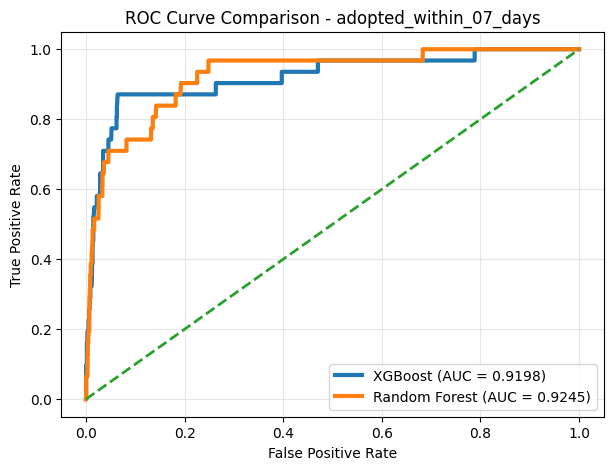


===== adopted_within_90_days =====

--- XGBoost ---
AUC: 0.9424713120118678
LogLoss: 0.05372629056938496

--- Random Forest ---
AUC: 0.9108905275099263
LogLoss: 0.05778619418879757


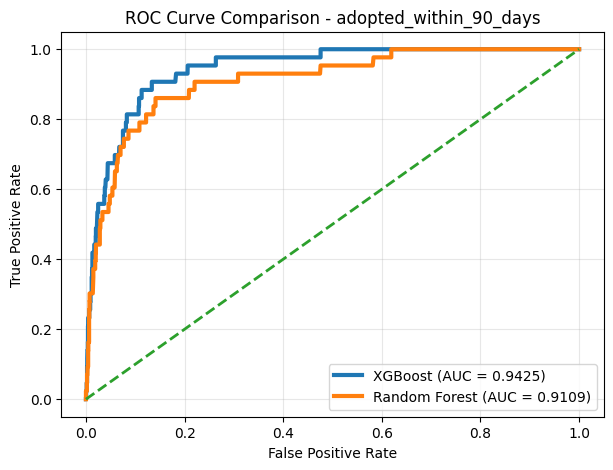


===== adopted_within_120_days =====

--- XGBoost ---
AUC: 0.8921103977844913
LogLoss: 0.0842136608965152

--- Random Forest ---
AUC: 0.8715288267875125
LogLoss: 0.07955970863632153


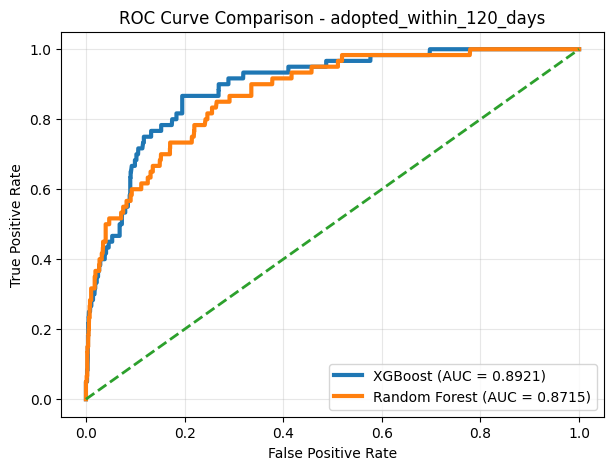

In [66]:
xgb_07, rf_07   = train_models("adopted_within_07_days")
xgb_90, rf_90   = train_models("adopted_within_90_days")
xgb_120, rf_120 = train_models("adopted_within_120_days")

In [67]:
submission = pd.read_csv(r"C:\Users\Yuvraj Bhavsar\OneDrive\Desktop\competition\DigiCow Farmer Training Adoption Challenge\SampleSubmission.csv")

submission["Target_07_AUC"] = xgb_07
submission["Target_07_LogLoss"] = xgb_07

submission["Target_90_AUC"] = xgb_90
submission["Target_90_LogLoss"] = xgb_90

submission["Target_120_AUC"] = xgb_120
submission["Target_120_LogLoss"] = xgb_120

submission.to_csv("Final_Submission_XGBoost.csv", index=False)

print("\nSubmission created successfully (XGBoost Only)")


Submission created successfully (XGBoost Only)
